# Ejercicios de K-Means y K-Medias

**K-means (k-medias) - Segmentación de clientes**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

clientes = pd.DataFrame({
    "saldo": [50000, 45000, 48000, 43500, 47000, 52000, 20000, 26000, 25000, 23000, 21400, 18000,
                8000, 12000, 6000, 14500, 12600, 7000],
    "transacciones": [25, 20, 16, 23, 25, 18,
                23, 22, 24, 21, 27, 18, 8, 3, 6, 4, 9, 3]
})

**Preprocesamiento**

In [ ]:
#Creamos un escalador en este caso el MinMaxScaler, que escala los datos a un rango entre 0 y 1
escalador=MinMaxScaler().fit(clientes.values)
#Transformamos los datos utilizando el escalador y los guardamos en un nuevo DataFrame
clientes=pd.DataFrame(escalador.transform(clientes.values),columns=["saldo","transacciones"])
clientes


,saldo,transacciones
0,0.956522,0.916667
1,0.847826,0.708333
2,0.913043,0.541667
3,0.815217,0.833333
4,0.891304,0.916667
5,1.000000,0.625000
6,0.304348,0.833333
7,0.434783,0.791667
8,0.413043,0.875000
9,0.369565,0.750000


**Generar el modelo K-means**

In [ ]:
#Aplicamos el algoritmo de KMeans a los datos escalados, indicando que queremos 3 clusters
kmeans=KMeans(n_clusters=3).fit(clientes.values)
#Obtenemos las etiquetas de cada punto, es decir, a que cluster pertenece cada cliente
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1], dtype=int32)

In [5]:
#Agregamos las etiquetas de los clusters al DataFrame original de clientes
clientes["cluster"]=kmeans.labels_
clientes

,saldo,transacciones,cluster
0,0.956522,0.916667,0
1,0.847826,0.708333,0
2,0.913043,0.541667,0
3,0.815217,0.833333,0
4,0.891304,0.916667,0
5,1.000000,0.625000,0
6,0.304348,0.833333,2
7,0.434783,0.791667,2
8,0.413043,0.875000,2
9,0.369565,0.750000,2


In [ ]:
# Obtenemos las coordenadas de los centros de cada cluster y la inercia del modelo
# inercia significa la suma de las distancias al cuadrado de cada punto a su centroide más cercano, 
# es decir, mide la calidad del modelo, cuanto menor sea la inercia mejor será el modelo
print(kmeans.cluster_centers_, kmeans.inertia_)


[[0.90398551 0.75694444]
 [0.08731884 0.10416667]
 [0.35289855 0.8125    ]] 0.33349688003220607


**Graficamos los clusters**

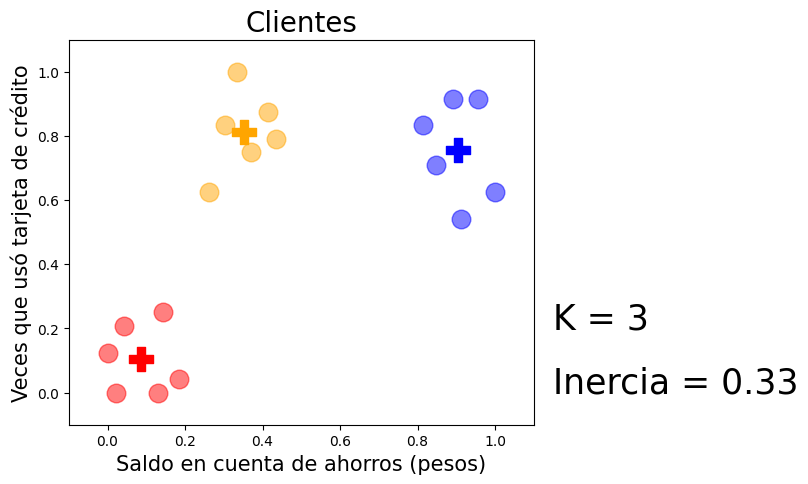

In [9]:
kmeans = KMeans(n_clusters=3).fit(clientes.values)

clientes["cluster"] = kmeans.labels_

# Instrucciones para graficar los clusters 

plt.figure(figsize=(6, 5), dpi=100)

colores = ["red", "blue", "orange", "black", "purple", "pink", "brown"]

for cluster in range(kmeans.n_clusters):
    plt.scatter(clientes[clientes["cluster"] == cluster]["saldo"],
                clientes[clientes["cluster"] == cluster]["transacciones"],
                marker="o", s=180, color=colores[cluster], alpha=0.5)
    
    plt.scatter(kmeans.cluster_centers_[cluster][0], 
                kmeans.cluster_centers_[cluster][1], 
                marker="P", s=280, color=colores[cluster])

plt.title("Clientes", fontsize=20)
plt.xlabel("Saldo en cuenta de ahorros (pesos)", fontsize=15)
plt.ylabel("Veces que usó tarjeta de crédito", fontsize=15)
plt.text(1.15, 0.2, "K = %i" % kmeans.n_clusters, fontsize=25)
plt.text(1.15, 0, "Inercia = %0.2f" % kmeans.inertia_, fontsize=25)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)    
plt.show()

del clientes["cluster"] 

**Método del codo**

Cálculo del número de Clústers (k)

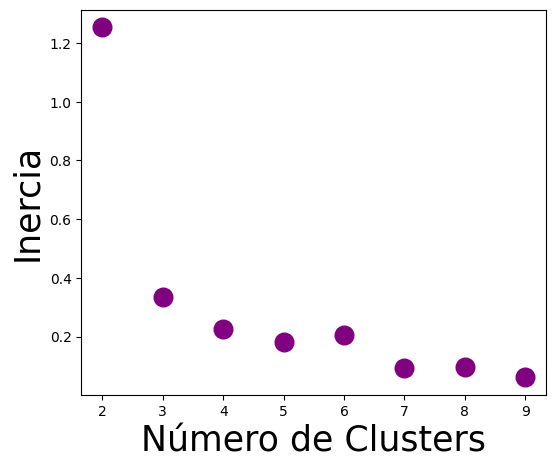

In [10]:
inercias = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k).fit(clientes.values)    
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(6, 5), dpi=100)
plt.scatter(range(2, 10), inercias, marker="o", s=180, color="purple")
plt.xlabel("Número de Clusters", fontsize=25)
plt.ylabel("Inercia", fontsize=25)
plt.show()

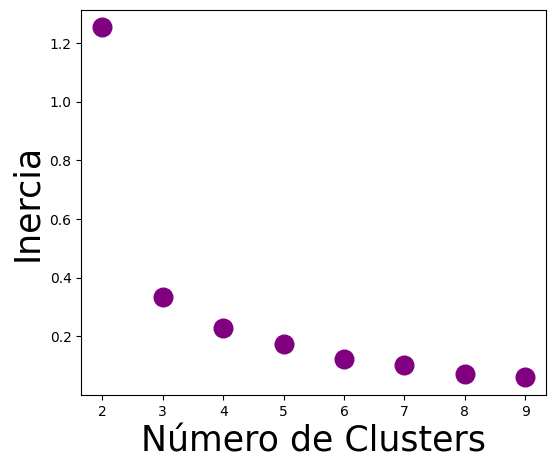

In [11]:
inercias = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(clientes.values)    
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(6, 5), dpi=100)
plt.scatter(range(2, 10), inercias, marker="o", s=180, color="purple")
plt.xlabel("Número de Clusters", fontsize=25)
plt.ylabel("Inercia", fontsize=25)
plt.show()